In [1]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.preprocessing import MinMaxScaler
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import precision_recall_curve
import numpy as np
import torch.nn as nn
from sklearn.metrics import classification_report, roc_auc_score
import joblib
from sklearn.metrics import confusion_matrix

# Loading Data

In [2]:
merged = pd.read_csv("/kaggle/input/datasets/vishala28/swat-dataset-secure-water-treatment-system/merged.csv")

# Data Exploring

In [3]:
merged.head()

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
0,28/12/2015 10:00:00 AM,2.427057,522.8467,2.0,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.5988,0.000128,1,1,1,Normal
1,28/12/2015 10:00:01 AM,2.446274,522.8860,2.0,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.6789,0.000128,1,1,1,Normal
2,28/12/2015 10:00:02 AM,2.489191,522.8467,2.0,2,1,262.0161,8.394514,328.6337,2.442316,...,2,1,250.8812,1.649953,189.6789,0.000128,1,1,1,Normal
3,28/12/2015 10:00:03 AM,2.534350,522.9645,2.0,2,1,262.0161,8.394514,328.6337,2.442316,...,2,1,250.8812,1.649953,189.6148,0.000128,1,1,1,Normal
4,28/12/2015 10:00:04 AM,2.569260,523.4748,2.0,2,1,262.0161,8.394514,328.6337,2.443085,...,2,1,250.8812,1.649953,189.5027,0.000128,1,1,1,Normal


In [4]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441719 entries, 0 to 1441718
Data columns (total 53 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0    Timestamp     1441719 non-null  object 
 1   FIT101         1441719 non-null  float64
 2   LIT101         1441719 non-null  float64
 3    MV101         449919 non-null   float64
 4   P101           1441719 non-null  int64  
 5   P102           1441719 non-null  int64  
 6    AIT201        449919 non-null   float64
 7   AIT202         1441719 non-null  float64
 8   AIT203         1441719 non-null  float64
 9   FIT201         1441719 non-null  float64
 10   MV201         449919 non-null   float64
 11   P201          449919 non-null   float64
 12   P202          449919 non-null   float64
 13  P203           1441719 non-null  int64  
 14   P204          449919 non-null   float64
 15  P205           1441719 non-null  int64  
 16  P206           1441719 non-null  int64  
 17  DPIT301 

In [5]:
merged.value_counts().sum()

np.int64(449919)

In [6]:
merged.isnull().sum()

 Timestamp            0
FIT101                0
LIT101                0
 MV101           991800
P101                  0
P102                  0
 AIT201          991800
AIT202                0
AIT203                0
FIT201                0
 MV201           991800
 P201            991800
 P202            991800
P203                  0
 P204            991800
P205                  0
P206                  0
DPIT301               0
FIT301                0
LIT301                0
MV301                 0
MV302                 0
 MV303           991800
MV304                 0
P301                  0
P302                  0
AIT401                0
AIT402                0
FIT401                0
LIT401                0
P401                  0
P402                  0
P403                  0
P404                  0
UV401                 0
AIT501                0
AIT502                0
AIT503                0
AIT504                0
FIT501                0
FIT502                0
FIT503          

In [7]:
merged["Normal/Attack"].value_counts()

Normal/Attack
Normal    1387098
Attack      54621
Name: count, dtype: int64

**total=1441719 then all labeled**

In [8]:
merged.duplicated().sum()

np.int64(494991)

1. Missing Values Pattern is Intentional
In SWaT, missing values often indicate:

Pumps/Valves being OFF (binary states like MV101, P201)

Sensors not recording during certain operational phases

Normal operational patterns (e.g., some components only active in specific treatment stages)

2. Duplicates are Expected
SWaT data is collected at regular intervals, but:

Same readings can occur during stable operation

Attack scenarios might create repeated patterns

Removing duplicates is safe as they don't add information

# Data Cleaning

In [9]:
def complete_swat_preprocessing(merged):

    print(f"Initial shape: {merged.shape}")
    print(f"Columns: {merged.columns.tolist()}")
    
    df_proc = merged.copy()
    
    # Fix column names - strip whitespace
    df_proc.columns = df_proc.columns.str.strip()
    
    # Step 2: Remove duplicates (safe for SWaT)
    initial_len = len(df_proc)
    df_proc = df_proc.drop_duplicates()
    print(f"Removed {initial_len - len(df_proc)} duplicate rows")
    
    # Step 3: Separate features and target
    target = df_proc['Normal/Attack']
    features = df_proc.drop(columns=['Normal/Attack','Timestamp'])
    
    # Step 4: Fix column names in features (strip whitespace)
    features.columns = features.columns.str.strip()
    
    # Step 5: Handle missing values based on SWaT domain knowledge
    # Binary actuators (fill with 0 for OFF state)
    binary_actuators = ['MV101', 'MV201', 'P201', 'P202', 'P204', 'MV303']
    for col in binary_actuators:
        matching_cols = [c for c in features.columns if c.strip() == col]
        if matching_cols:
            actual_col = matching_cols[0]
            features[actual_col] = features[actual_col].fillna(0)
            features[actual_col] = features[actual_col].astype(int)
            if actual_col != col:
                features = features.rename(columns={actual_col: col})
    
    # Critical continuous sensors (interpolate)
    critical_sensors = ['LIT101', 'AIT201', 'AIT202', 'FIT401', 'PIT501']
    for col in critical_sensors:
        matching_cols = [c for c in features.columns if c.strip() == col]
        if matching_cols:
            actual_col = matching_cols[0]
            features[actual_col] = features[actual_col].interpolate(method='linear', limit_direction='both') #Linear interpolation fills missing values based on surrounding values.
            if actual_col != col:
                features = features.rename(columns={actual_col: col})
    
    # Other sensors (fill with forward fill then median)
    numeric_cols = features.select_dtypes(include=[np.number]).columns
    other_sensors = [col for col in numeric_cols if col not in binary_actuators + critical_sensors]
    for col in other_sensors:
        features[col] = features[col].ffill().fillna(features[col].median())
    
    
    # Step 7: Encode target
    if target.dtype == 'object':
        target_encoded = (target.str.strip() == 'Attack').astype(int)
    else:
        target_encoded = target
    
    print(f"\nFinal shape: {features.shape}")
    print(f"Missing values: {features.isnull().sum().sum()}")
    print(f"Attack samples: {target_encoded.sum()}")
    print(f"Normal samples: {len(target_encoded) - target_encoded.sum()}")
    
    return features, target_encoded

In [10]:
X_swat, y_swat = complete_swat_preprocessing(merged)


print(f" Features shape: {X_swat.shape}")
print(f" Target shape: {y_swat.shape}")
print(f" Attack samples: {y_swat.sum()} ({y_swat.mean()*100:.2f}%)")
print(f" Normal samples: {len(y_swat) - y_swat.sum()} ({(1-y_swat.mean())*100:.2f}%)")
print(f" Missing values in features: {X_swat.isnull().sum().sum()}")

Initial shape: (1441719, 53)
Columns: [' Timestamp', 'FIT101', 'LIT101', ' MV101', 'P101', 'P102', ' AIT201', 'AIT202', 'AIT203', 'FIT201', ' MV201', ' P201', ' P202', 'P203', ' P204', 'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', ' MV303', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603', 'Normal/Attack']
Removed 494991 duplicate rows

Final shape: (946728, 51)
Missing values: 0
Attack samples: 54621
Normal samples: 892107
 Features shape: (946728, 51)
 Target shape: (946728,)
 Attack samples: 54621 (5.77%)
 Normal samples: 892107 (94.23%)
 Missing values in features: 0


**Preprocessing Results Summary:**

Original rows:	1,441,719

After removing duplicates:	946,719

Duplicates removed:	495,000 (34.3%)

Features (columns):	57

Missing values:	0 

Attack samples:	54,621 (5.77%)

Normal samples:	892,098 (94.23%)

Time range:	Dec 22, 2015 - Jan 2, 2016

**For USAD, typically:**

**Train mostly on Normal data**

**Test on Normal + Attack**

If shuffled:

The model may see future patterns

Data leakage happens

In [11]:
#finding attack indecies
attack_indices = y_swat[y_swat == 1].index

print("First attack:", attack_indices.min())
print("Last attack:", attack_indices.max())
print("Total attacks:", len(attack_indices))

First attack: 1387098
Last attack: 1441718
Total attacks: 54621


# Splitting the data

In [12]:
split_index = int(len(X_swat) * 0.7)

X_train = X_swat.iloc[:split_index]
y_train = y_swat.iloc[:split_index]

X_test = X_swat.iloc[split_index:]
y_test = y_swat.iloc[split_index:]

In [13]:
print("Train attacks:", y_train.sum())
print("Test attacks:", y_test.sum())

Train attacks: 0
Test attacks: 54621


this is perfect for USAD beacause now i have Train mostly on Normal data and

Test on Normal + Attack

# Normalization

In [14]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Preparing for the USAD

In [15]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

In [16]:
train_dataset = TensorDataset(X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=False)

In [17]:
next(iter(train_loader))[0].shape

torch.Size([1024, 51])

In [18]:
input_dim = X_train.shape[1]  # should be 51
print(input_dim)

51


**so the neural should be:**

Input Layer: 51 neurons

↓

Encoder

↓

Latent Space

↓

Decoder1

Decoder2


# Implementing the model

In [19]:
input_dim = 51
hidden_dim = 25
latent_dim = 12


class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)


class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(z)

In [20]:
class USAD(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = Encoder()
        self.decoder1 = Decoder()
        self.decoder2 = Decoder()

    def forward(self, x):

        z = self.encoder(x)

        w1 = self.decoder1(z)
        w2 = self.decoder2(z)

        z2 = self.encoder(w1)
        w3 = self.decoder2(z2)

        return w1, w2, w3

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = USAD().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

epochs = 30

In [22]:
for epoch in range(epochs):

    model.train()
    total_loss = 0

    for batch in train_loader:

        x = batch[0].to(device)

        w1, w2, w3 = model(x)

        mse1 = torch.mean((x - w1)**2)
        mse2 = torch.mean((x - w2)**2)
        mse3 = torch.mean((x - w3)**2)

        n = epoch + 1

        loss1 = (1/n)*mse1 + (1 - 1/n)*mse3
        loss2 = (1/n)*mse2 - (1 - 1/n)*mse3

        loss = loss1 + loss2

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} Loss: {total_loss:.4f}")

Epoch 1/30 Loss: 68.7209
Epoch 2/30 Loss: 24.0557
Epoch 3/30 Loss: 11.7039
Epoch 4/30 Loss: 7.8032
Epoch 5/30 Loss: 5.3008
Epoch 6/30 Loss: 3.8214
Epoch 7/30 Loss: 2.8653
Epoch 8/30 Loss: 2.2493
Epoch 9/30 Loss: 1.8016
Epoch 10/30 Loss: 1.4845
Epoch 11/30 Loss: 1.2528
Epoch 12/30 Loss: 1.0824
Epoch 13/30 Loss: 0.9309
Epoch 14/30 Loss: 0.7929
Epoch 15/30 Loss: 0.6878
Epoch 16/30 Loss: 0.5932
Epoch 17/30 Loss: 0.5082
Epoch 18/30 Loss: 0.4248
Epoch 19/30 Loss: 0.3572
Epoch 20/30 Loss: 0.3045
Epoch 21/30 Loss: 0.2624
Epoch 22/30 Loss: 0.2305
Epoch 23/30 Loss: 0.2060
Epoch 24/30 Loss: 0.1862
Epoch 25/30 Loss: 0.1692
Epoch 26/30 Loss: 0.1544
Epoch 27/30 Loss: 0.1424
Epoch 28/30 Loss: 0.1335
Epoch 29/30 Loss: 0.1255
Epoch 30/30 Loss: 0.1188


In [23]:
model.eval()

X_test_tensor = X_test_tensor.to(device)

with torch.no_grad():

    w1, w2, w3 = model(X_test_tensor)

    error1 = torch.mean((X_test_tensor - w1) ** 2, dim=1)
    error2 = torch.mean((X_test_tensor - w3) ** 2, dim=1)

    anomaly_score = 0.7*error1 + 0.3*error2 #weighted score

anomaly_score = anomaly_score.cpu().numpy()

# Find the best threshold automatically

In [24]:
precision, recall, thresholds = precision_recall_curve(y_test, anomaly_score)

f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1)

best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", f1[best_idx])

Best threshold: 0.016086582
Best F1: 0.8914216521417714


In [25]:
y_pred = (anomaly_score > best_threshold).astype(int)

# Evaluation

In [26]:
print(classification_report(y_test, y_pred))

roc = roc_auc_score(y_test, anomaly_score)

print("ROC AUC:", roc)

              precision    recall  f1-score   support

           0       0.96      0.99      0.98    229398
           1       0.95      0.84      0.89     54621

    accuracy                           0.96    284019
   macro avg       0.96      0.91      0.93    284019
weighted avg       0.96      0.96      0.96    284019

ROC AUC: 0.9725142142922504


[[227216   2182]
 [  8946  45675]]


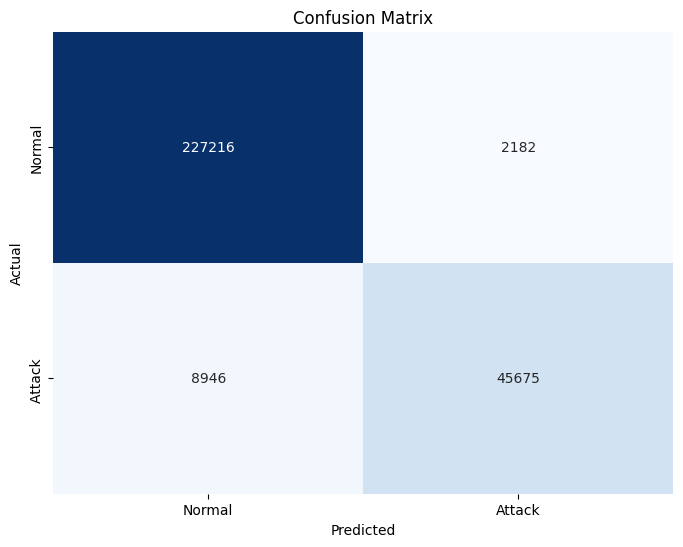

In [29]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm= confusion_matrix(y_test, y_pred)
print(confusion_matrix(y_test, y_pred))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack '])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

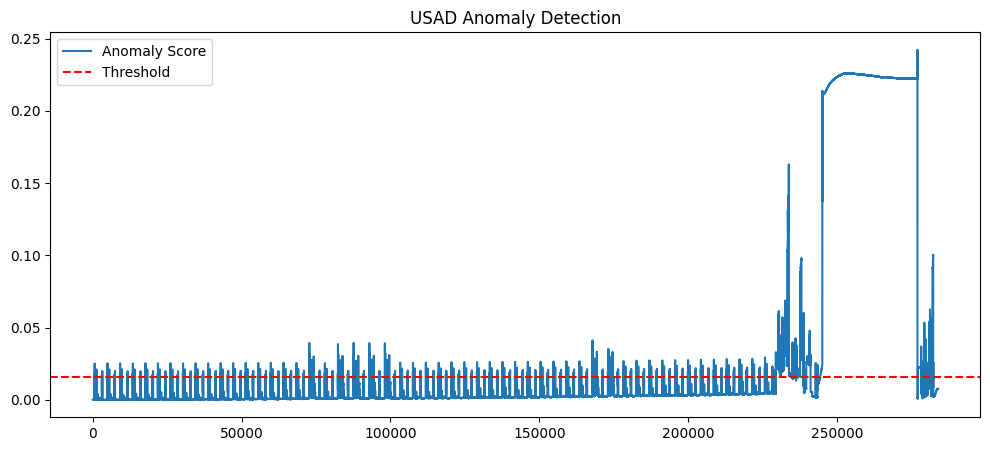

In [30]:
plt.figure(figsize=(12,5))

plt.plot(anomaly_score, label="Anomaly Score")
plt.axhline(best_threshold, color="red", linestyle="--", label="Threshold")

plt.legend()
plt.title("USAD Anomaly Detection")

plt.show()

In [34]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, anomaly_score)

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

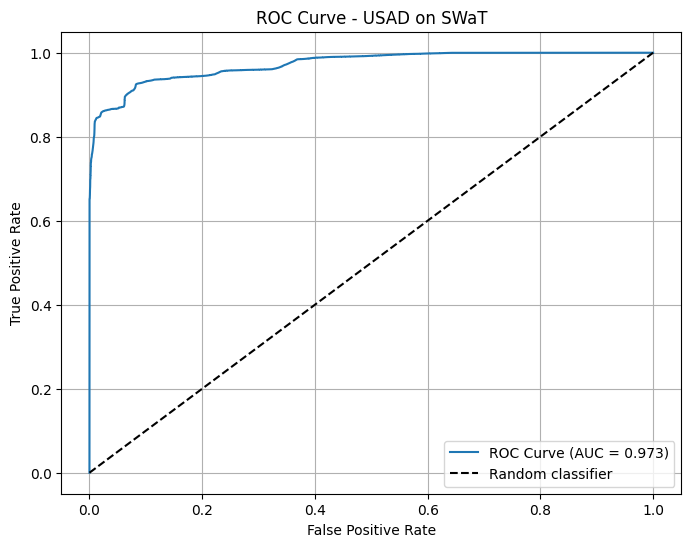

In [35]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc:.3f})")
plt.plot([0,1],[0,1],'k--',label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - USAD on SWaT")
plt.legend()
plt.grid(True)

plt.show()

# Saving

In [36]:
torch.save(model.state_dict(), "usad_swat_weights.pth")

In [37]:
torch.save(model, "usad_swat_model_full.pth")

In [38]:
joblib.dump(scaler, "swat_scaler.pkl")

['swat_scaler.pkl']

In [39]:
plt.savefig("roc_curve_usad_swat.png", dpi=300)

<Figure size 640x480 with 0 Axes>